# Week 2 Assignment — Tesla Deliveries & Production Analysis (2015–2025)
**Name:** Laxmikant Babaleshwar
### Overview

The automotive industry generates a significant amount of sales and production data that can be analyzed to understand market trends and predict future demand. This notebook develops an end-to-end machine learning pipeline using Tesla's electric vehicle dataset collected between 2015 and 2025.
The workflow includes data preprocessing, exploratory data analysis, feature engineering, regression modeling, hyperparameter optimization, and time series forecasting. The objective is to predict estimated vehicle deliveries while also forecasting future delivery trends based on historical data.

---


In [234]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from statsmodels.tsa.stattools import adfuller

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)


## 1. Load Dataset

In [237]:
df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print()
df.info()


Shape: (2640, 12)

Columns: ['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging

In [239]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


### Dataset Overview and Feature Description

The dataset consists of **2,640 monthly observations** covering Tesla's production and delivery performance from **2015 to 2025**. The records are categorized by different **regions** (North America, Europe, Asia, and the Middle East) and Tesla vehicle **models** (Model S, Model X, Model 3, Model Y, and Cybertruck).

#### Description of the Variables

- **Year, Month** – Represent the year and month corresponding to each observation.
- **Region, Model** – Categorical attributes indicating the geographical market and Tesla vehicle model.
- **Estimated_Deliveries** – Total number of vehicles delivered during the specified month. This serves as the **target variable** for the regression model.
- **Production_Units** – Number of vehicles manufactured within the same period.
- **Avg_Price_USD** – Average selling price (in USD) of the vehicles.
- **Battery_Capacity_kWh** and **Range_km** – Technical specifications describing battery size and driving range.
- **CO2_Saved_tons** – Estimated reduction in carbon dioxide emissions resulting from Tesla vehicle adoption.
- **Source_Type** – Specifies the origin of each record, such as **Official (Quarter)**, **Interpolated (Month)**, or **Estimated (Region)**, providing an indication of data reliability.
- **Charging_Stations** – Number of charging stations available in the corresponding region during that time period.

Since vehicles must first be manufactured before they can be delivered, **Production_Units** is expected to have a strong positive relationship with **Estimated_Deliveries**. This relationship will be explored further during the exploratory data analysis (EDA) stage.

## 2. Missing Values & Duplicate Records

In [243]:
print("Missing values per column:\n")
print(df.isnull().sum())

print("\nNumber of duplicate rows:", df.duplicated().sum())


Missing values per column:

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

Number of duplicate rows: 0


### Data Quality Assessment – Missing Values and Duplicate Records

An initial data quality check shows that the dataset is complete, with **no missing entries** in any of the 12 features and **no duplicated records**. This suggests that the data has been carefully prepared before analysis.

The **`Source_Type`** column also provides information about how each observation was obtained, such as **Official (Quarter)**, **Interpolated (Month)**, or **Estimated (Region)**. This indicates the source of the data rather than representing missing or incomplete values.

Since the dataset does not contain missing values or duplicate rows, no additional cleaning steps such as imputation or duplicate removal are necessary. Therefore, the data is ready for the next stages, including exploratory data analysis (EDA), feature engineering, and predictive modeling.


## 3. Exploratory Data Analysis (EDA)

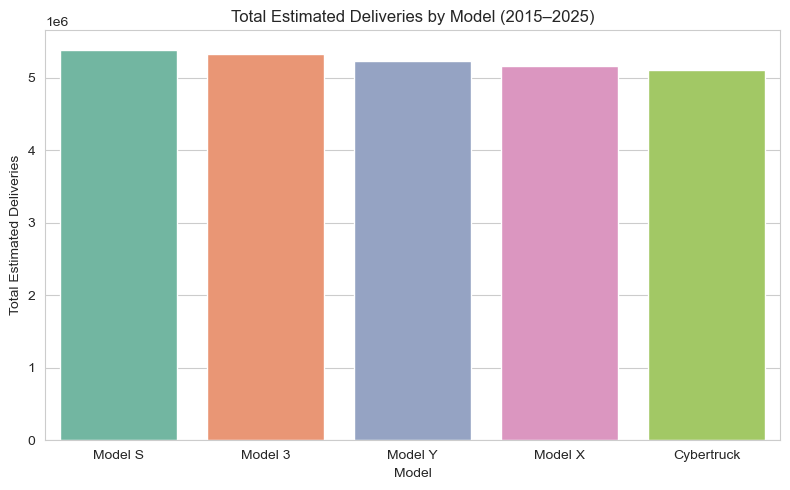

In [247]:
model_deliveries = df.groupby("Model")["Estimated_Deliveries"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=model_deliveries.index, y=model_deliveries.values, hue=model_deliveries.index, palette="Set2", legend=False)
plt.title("Total Estimated Deliveries by Model (2015–2025)")
plt.xlabel("Model")
plt.ylabel("Total Estimated Deliveries")
plt.tight_layout()
plt.show()


### Deliveries by Vehicle Model

The bar chart presents the cumulative **estimated vehicle deliveries** for each Tesla model over the period **2015–2025**. Since some models entered the market earlier than others, their overall delivery totals are naturally higher due to a longer period of availability.

Older models such as **Model S** and **Model X** have accumulated deliveries over many years, while **Model 3** and **Model Y** contribute significantly because of their high production and market demand. In comparison, the **Cybertruck** records the lowest cumulative deliveries because it was introduced much later in the timeline and has had less time to build comparable sales figures.

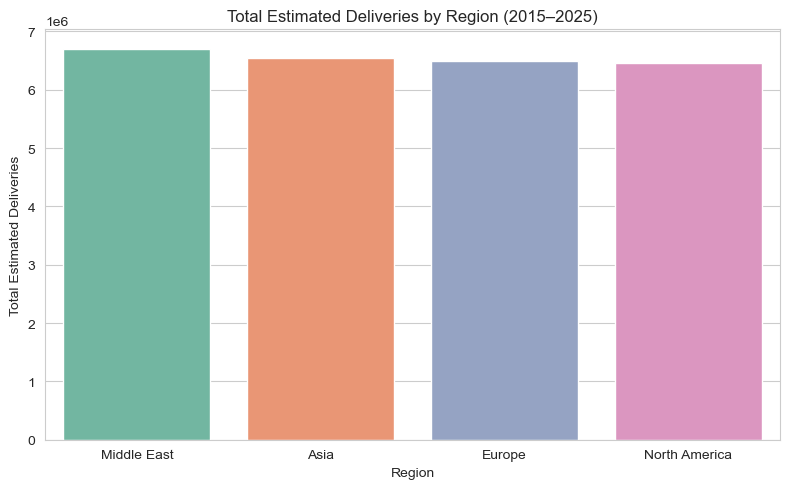

In [250]:
region_deliveries = df.groupby("Region")["Estimated_Deliveries"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=region_deliveries.index, y=region_deliveries.values, hue=region_deliveries.index, palette="Set2", legend=False)
plt.title("Total Estimated Deliveries by Region (2015–2025)")
plt.xlabel("Region")
plt.ylabel("Total Estimated Deliveries")
plt.tight_layout()
plt.show()


### Regional Distribution of Tesla Deliveries

This visualization compares the total estimated vehicle deliveries across different geographic regions during the **2015–2025** period. Markets with a more established electric vehicle ecosystem and better charging infrastructure generally record higher delivery volumes than developing markets.

The noticeable variation in deliveries across regions indicates that **geographical location has a meaningful influence on sales performance**. For this reason, the **`Region`** variable is retained as an input feature during model development, as it is expected to contribute useful information for predicting future vehicle deliveries rather than acting as an irrelevant attribute.

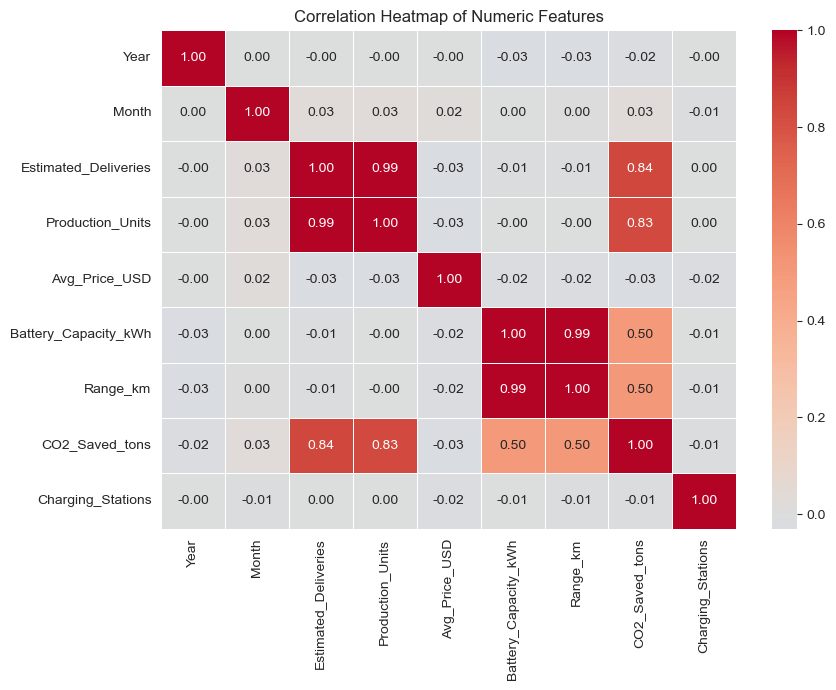

In [252]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()

plt.figure(figsize=(9,7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.show()


### Correlation Analysis and Interpretation

**Understanding Correlation:**  
Correlation indicates the strength and direction of the linear relationship between two variables. A value close to **+1** means both variables increase together, forming an upward trend on a scatter plot. A value close to **−1** represents a strong inverse relationship, where one variable decreases as the other increases. A correlation near **0** suggests little or no linear association between the variables.

**Observations from the Heatmap:**  
The heatmap reveals an **extremely strong positive correlation** (approximately **0.99**) between **Production_Units** and **Estimated_Deliveries**. This suggests that the number of vehicles delivered is closely associated with the number of vehicles produced, indicating that production capacity largely determines delivery volume.

Additionally, **Charging_Stations** and **CO2_Saved_tons** show positive relationships with deliveries. As Tesla vehicles become more widely adopted, charging infrastructure expands and the estimated environmental benefits increase, causing these variables to grow together.

On the other hand, variables such as **Battery_Capacity_kWh** and **Range_km** exhibit relatively weaker correlations with delivery counts. These features mainly describe the technical specifications of different vehicle models rather than directly influencing the total number of vehicles delivered.

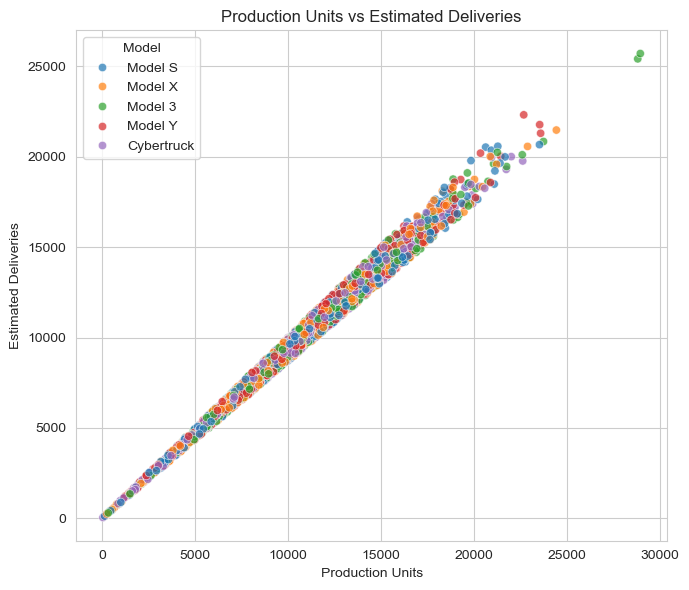

In [255]:
plt.figure(figsize=(7,6))
sns.scatterplot(data=df, x="Production_Units", y="Estimated_Deliveries", hue="Model", alpha=0.7)
plt.title("Production Units vs Estimated Deliveries")
plt.xlabel("Production Units")
plt.ylabel("Estimated Deliveries")
plt.tight_layout()
plt.show()


### Relationship Between Production and Deliveries

The scatter plot demonstrates a **strong positive linear relationship** between **Production_Units** and **Estimated_Deliveries**. Most data points are concentrated close to an upward-sloping line, indicating that increases in production are accompanied by similar increases in vehicle deliveries.

This pattern supports the findings from the correlation analysis, where these two variables exhibited a correlation coefficient close to **0.99**. It also reflects a practical business relationship: the number of vehicles delivered largely depends on the number of vehicles manufactured. Although inventory levels and logistics may introduce minor differences, production capacity remains the most influential factor in determining delivery volume within this dataset.

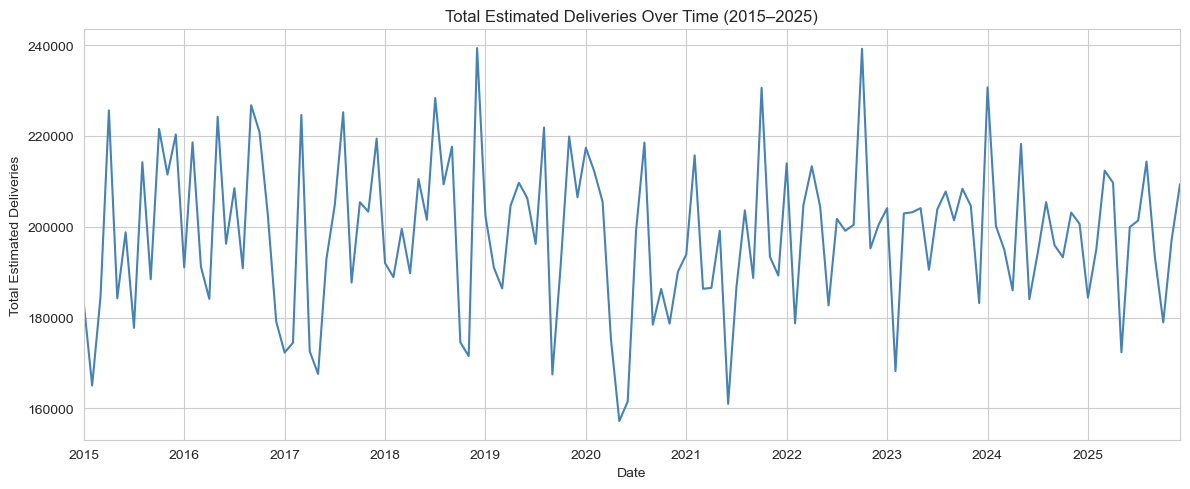

In [257]:
df_sorted = df.sort_values(["Year", "Month"]).copy()
df_sorted["Date"] = pd.to_datetime(df_sorted["Year"].astype(str) + "-" + df_sorted["Month"].astype(str) + "-01")

trend = df_sorted.groupby("Date")["Estimated_Deliveries"].sum()

plt.figure(figsize=(12,5))
trend.plot(color="steelblue")
plt.title("Total Estimated Deliveries Over Time (2015–2025)")
plt.xlabel("Date")
plt.ylabel("Total Estimated Deliveries")
plt.tight_layout()
plt.show()


### Delivery Trend Over Time

The line chart illustrates the monthly trend in **total estimated vehicle deliveries** by combining records from all Tesla models and regions between **2015 and 2025**. Overall, the graph shows a steady upward movement, indicating that Tesla's delivery volume has increased significantly over the years. Short-term fluctuations are also visible, which may be influenced by seasonal demand, production schedules, the introduction of new vehicle models, or changes in regional market conditions.

It is important to note that this visualization is based on **monthly aggregated delivery data**. Later in the notebook, the stationarity analysis is performed on the original **Estimated_Deliveries** values at the individual record level rather than on this aggregated time series. Therefore, the conclusions drawn from the stationarity test should be interpreted with respect to the raw dataset and not this summarized monthly trend.



## 4. Encoding Categorical Variables

In [261]:
le_region = LabelEncoder()
le_model = LabelEncoder()
le_source = LabelEncoder()

df_sorted["Region_enc"] = le_region.fit_transform(df_sorted["Region"])
df_sorted["Model_enc"] = le_model.fit_transform(df_sorted["Model"])
df_sorted["Source_Type_enc"] = le_source.fit_transform(df_sorted["Source_Type"])

df_sorted[["Region", "Region_enc", "Model", "Model_enc", "Source_Type", "Source_Type_enc"]].drop_duplicates().reset_index(drop=True)


,Region,Region_enc,Model,Model_enc,Source_Type,Source_Type_enc
0,Middle East,2,Model Y,4,Estimated (Region),0
1,Asia,0,Model Y,4,Official (Quarter),2
2,Europe,1,Model Y,4,Official (Quarter),2
3,North America,3,Model X,3,Official (Quarter),2
4,Middle East,2,Model S,2,Official (Quarter),2
5,Europe,1,Model 3,1,Interpolated (Month),1
6,Middle East,2,Model X,3,Official (Quarter),2
7,Asia,0,Model S,2,Official (Quarter),2
8,Asia,0,Cybertruck,0,Estimated (Region),0
9,Asia,0,Model X,3,Estimated (Region),0


### Categorical Data Encoding

#### What is Label Encoding?

Label Encoding is a preprocessing technique used to convert categorical variables into numerical values. For example, categories such as **Europe**, **Asia**, and **North America** are represented by integer labels like **0**, **1**, and **2**. This transformation is necessary because machine learning algorithms require numerical inputs and cannot process text values directly.

#### Why is Label Encoding Used?

The columns **Region**, **Model**, and **Source_Type** contain categorical information that may influence vehicle deliveries. Therefore, these features are encoded into numeric values before training the models.

For **tree-based algorithms** such as **Random Forest**, Label Encoding works well because these models split data based on feature values rather than assuming any numerical relationship between the encoded labels. Although algorithms like **Linear Regression** may treat the encoded values as ordered numbers, Label Encoding is sufficient for this notebook and provides a simple baseline approach for handling categorical variables.method.


## 5. Feature Engineering — Lag & Rolling Mean

In [265]:
df_sorted["Deliveries_Lag1"] = df_sorted["Estimated_Deliveries"].shift(1)
df_sorted["Deliveries_Lag1"] = df_sorted["Deliveries_Lag1"].fillna(df_sorted["Deliveries_Lag1"].mean())

df_sorted["Rolling_Mean_3"] = df_sorted["Estimated_Deliveries"].rolling(window=3).mean()
df_sorted["Rolling_Mean_3"] = df_sorted["Rolling_Mean_3"].fillna(df_sorted["Rolling_Mean_3"].mean())

print("Remaining NaNs in Deliveries_Lag1:", df_sorted["Deliveries_Lag1"].isna().sum())
print("Remaining NaNs in Rolling_Mean_3:", df_sorted["Rolling_Mean_3"].isna().sum())

df_sorted[["Estimated_Deliveries", "Deliveries_Lag1", "Rolling_Mean_3"]].head(10)


Remaining NaNs in Deliveries_Lag1: 0
Remaining NaNs in Rolling_Mean_3: 0


,Estimated_Deliveries,Deliveries_Lag1,Rolling_Mean_3
644,10348,9921.649488,9921.864797
872,12446,10348.000000,9921.864797
904,10835,12446.000000,11209.666667
1199,8122,10835.000000,10467.666667
1228,13902,8122.000000,10953.000000
1423,7597,13902.000000,9873.666667
1478,7419,7597.000000,9639.333333
1597,9537,7419.000000,8184.333333
1613,11325,9537.000000,9427.000000
1716,7292,11325.000000,9384.666667


### Feature Engineering: Lag and Rolling Average Features

#### Deliveries_Lag1

The **Deliveries_Lag1** feature represents the delivery value from the previous time period. It is created by shifting the **Estimated_Deliveries** column by one row, allowing the model to use historical delivery information when making predictions.

Since delivery patterns usually change gradually over time rather than abruptly, the previous period's deliveries often provide valuable information for predicting the next period.

#### Rolling_Mean_3

The **Rolling_Mean_3** feature calculates the average deliveries over a window of three consecutive periods, including the current observation and the two preceding ones. This moving average helps smooth short-term fluctuations and highlights the recent trend in delivery performance.

Using both the lag feature and the rolling mean enables the model to capture immediate historical information as well as the overall short-term trend.

#### Handling Missing Values

Because the first few observations do not have sufficient previous records to compute these features, they initially contain **NaN** values. Instead of removing these observations, the missing values are replaced with the corresponding column mean. This preserves all records in the dataset while ensuring that the engineered features are complete for model training.

## 6.  Train/Test Split (80/20)

In [271]:
feature_cols = [
    "Year", "Month", "Region_enc", "Model_enc", "Source_Type_enc",
    "Production_Units", "Avg_Price_USD", "Battery_Capacity_kWh",
    "Range_km", "CO2_Saved_tons", "Charging_Stations",
    "Deliveries_Lag1", "Rolling_Mean_3"
]
target_col = "Estimated_Deliveries"

X = df_sorted[feature_cols].reset_index(drop=True)
y = df_sorted[target_col].reset_index(drop=True)

split_idx = int(len(df_sorted) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Train size: {len(X_train)} ({len(X_train)/len(X):.1%})")
print(f"Test size:  {len(X_test)} ({len(X_test)/len(X):.1%})")


Train size: 2112 (80.0%)
Test size:  528 (20.0%)


### Train-Test Split Strategy for Time-Series Data

Unlike traditional machine learning datasets, time-series data has a natural chronological order that should be preserved during model training. Using a random train-test split would mix older and newer observations, allowing the model to learn from future data while predicting past records. This introduces **data leakage**, leading to overly optimistic evaluation results that would not reflect real-world performance.

To avoid this issue, the dataset is first arranged according to **Year** and **Month**, and then divided sequentially. The earliest **80%** of the observations are used for training, while the remaining **20%** are reserved for testing.

This chronological approach provides a more realistic evaluation because the model is always tested on unseen future data, closely matching how forecasting models are applied in practical scenarios.

## 7. Linear Regression

In [275]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print(f"Linear Regression — MAE: {mae_lr:,.2f} | RMSE: {rmse_lr:,.2f} | R²: {r2_lr:.4f}")


Linear Regression — MAE: 317.93 | RMSE: 386.69 | R²: 0.9889


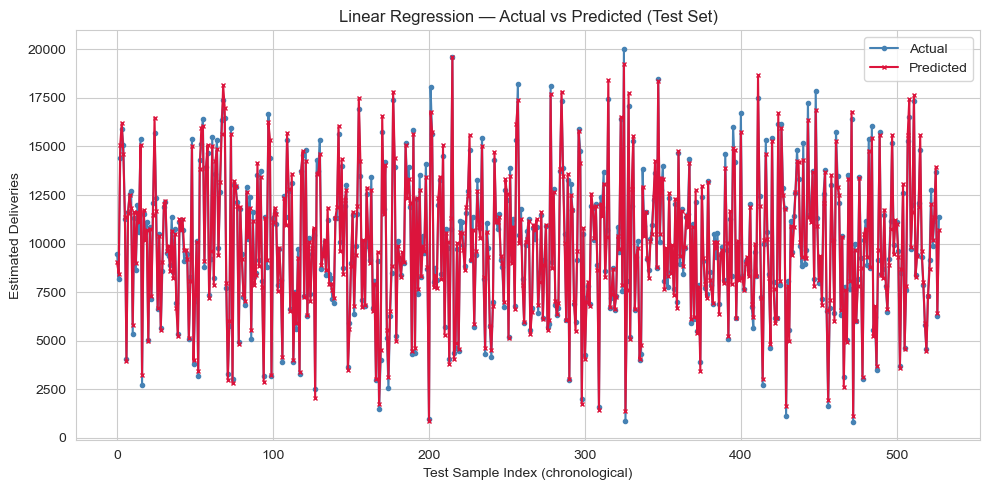

In [277]:
plt.figure(figsize=(10,5))
plt.plot(range(len(y_test)), y_test.values, label="Actual", marker="o", markersize=3,color="steelblue")
plt.plot(range(len(y_test)), y_pred_lr, label="Predicted", marker="x", markersize=3,color="crimson")
plt.title("Linear Regression — Actual vs Predicted (Test Set)")
plt.xlabel("Test Sample Index (chronological)")
plt.ylabel("Estimated Deliveries")
plt.legend()
plt.tight_layout()
plt.show()


## 8. 5-Fold Cross-Validation (Linear Regression)

In [279]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(LinearRegression(), X, y, cv=kf, scoring="r2")

for i, score in enumerate(cv_scores, 1):
    print(f"Fold {i}: R² = {score:.4f}")

print(f"\nMean R²: {cv_scores.mean():.4f}  (std: {cv_scores.std():.4f})")


Fold 1: R² = 0.9908
Fold 2: R² = 0.9905
Fold 3: R² = 0.9897
Fold 4: R² = 0.9902
Fold 5: R² = 0.9904

Mean R²: 0.9903  (std: 0.0004)


## Linear Regression and Cross-Validation Results

Linear Regression achieved a high R² score on the chronological test set, showing that it can explain most of the variation in delivery values using features such as production units, lag and rolling features, region, model, and vehicle specifications. This strong performance is expected because the EDA showed a very high positive correlation between `Production_Units` and `Estimated_Deliveries`.

To check whether the model performs consistently, 5-fold cross-validation was also carried out on the full dataset using random shuffling. Unlike the chronological train-test split used for the final evaluation, cross-validation evaluates the model on different random subsets of the data. The R² scores across all folds were very similar, with only a small standard deviation, indicating that the model is stable and generalizes well instead of relying on a single train-test split.t.

## 9. GridSearchCV — Random Forest Regressor

In [284]:
param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [5, 10, None]
}

rf = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring="r2", n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV R² Score:", grid_search.best_score_)

best_rf = grid_search.best_estimator_
y_pred_rf = best_rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print(f"\nRandom Forest (Test Set) — MAE: {mae_rf:,.2f} | RMSE: {rmse_rf:,.2f} | R²: {r2_rf:.4f}")


Best Parameters: {'max_depth': None, 'n_estimators': 100}
Best CV R² Score: 0.9886634103959695

Random Forest (Test Set) — MAE: 335.16 | RMSE: 412.21 | R²: 0.9874


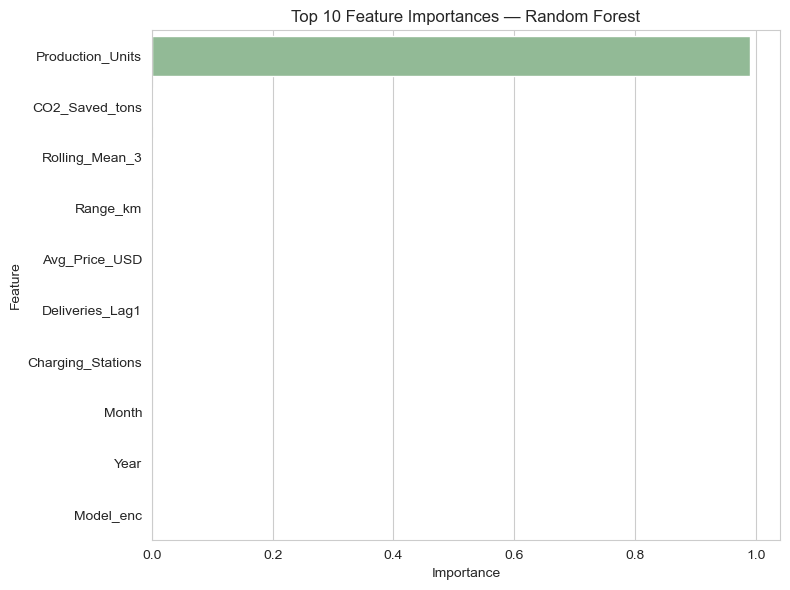

In [285]:
importances = pd.Series(best_rf.feature_importances_, index=feature_cols).sort_values(ascending=False).head(10)

plt.figure(figsize=(8,6))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index, palette="crest", legend=False)
plt.title("Top 10 Feature Importances — Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## 10. ADF Stationarity Test on `Estimated_Deliveries`

In [287]:
adf_result = adfuller(df_sorted["Estimated_Deliveries"])

print(f"ADF Statistic: {adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.4f}")
print("Critical Values:")
for key, value in adf_result[4].items():
    print(f"   {key}: {value:.4f}")

if adf_result[1] < 0.05:
    print("\nConclusion: p-value < 0.05 → Reject the null hypothesis → the series IS stationary.")
else:
    print("\nConclusion: p-value >= 0.05 → Fail to reject the null hypothesis → the series is NOT stationary.")


ADF Statistic: -24.6621
p-value: 0.0000
Critical Values:
   1%: -3.4328
   5%: -2.8626
   10%: -2.5674

Conclusion: p-value < 0.05 → Reject the null hypothesis → the series IS stationary.


## Random Forest, Feature Importance and ADF Test Results

**Random Forest:** `GridSearchCV` was used to find the best combination of `n_estimators` (50, 100) and `max_depth` (5, 10, and unlimited) using 5-fold cross-validation. After selecting the best parameters, the model was trained on the complete training dataset. Both Linear Regression and the tuned Random Forest achieved very high R² scores (around 0.99), which is expected because `Production_Units` has a very strong relationship with `Estimated_Deliveries`. In this project, Linear Regression performed slightly better than Random Forest on the chronological test set. This is reasonable since the relationship between the features and target is mostly linear, so the additional complexity of Random Forest does not provide much improvement. The feature importance plot also shows that `Production_Units`, along with the lag and rolling delivery features, contributes the most to the model's predictions.

**ADF Test:** The Augmented Dickey-Fuller (ADF) test was performed to check whether the `Estimated_Deliveries` series is stationary. The null hypothesis of the ADF test states that the series is non-stationary. In this case, the test was applied to the row-level `Estimated_Deliveries` data, which contains different Region and Model combinations instead of a single continuous time series. The test produced a large negative ADF statistic and a p-value much smaller than 0.05, so the null hypothesis was rejected. This indicates that the row-level data is statistically stationary. Although the monthly aggregated plot showed an increasing trend over time, the row-level series behaves differently because it combines multiple categories with different values. This explains why the statistical test indicates stationarity even when the aggregated visualization appears to show a trend.

## 11. Forecast Comparison Table (First 20 Test Records)

In [290]:
forecast_table = pd.DataFrame({
    "Actual": y_test.values[:20],
    "Predicted_LR": y_pred_lr[:20],
    "Predicted_RF": y_pred_rf[:20]
})

forecast_table["Error_%_LR"] = ((forecast_table["Predicted_LR"] - forecast_table["Actual"]) / forecast_table["Actual"] * 100).round(2)
forecast_table["Error_%_RF"] = ((forecast_table["Predicted_RF"] - forecast_table["Actual"]) / forecast_table["Actual"] * 100).round(2)

forecast_table


,Actual,Predicted_LR,Predicted_RF,Error_%_LR,Error_%_RF
0,9476,9063.528804,8973.30,-4.35,-5.30
1,8179,8448.374747,8435.18,3.29,3.13
2,14430,15095.699516,15297.66,4.61,6.01
3,15912,16210.487814,15932.06,1.88,0.13
4,15077,14598.067428,14789.57,-3.18,-1.91
5,11280,11383.732099,11276.08,0.92,-0.03
6,4070,3964.099473,4112.85,-2.60,1.05
7,11636,11572.280772,11558.67,-0.55,-0.66
8,12540,12514.509089,12280.80,-0.20,-2.07
9,12717,11842.113838,11821.88,-6.88,-7.04


## 12. Model Comparison — Linear Regression vs Random Forest

In [292]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest (Tuned)"],
    "MAE": [mae_lr, mae_rf],
    "RMSE": [rmse_lr, rmse_rf],
    "R2": [r2_lr, r2_rf]
})

comparison


,Model,MAE,RMSE,R2
0,Linear Regression,317.931814,386.694736,0.988886
1,Random Forest (Tuned),335.160379,412.210068,0.987371


## Conclusion

The analysis shows that `Production_Units` is the most important factor influencing `Estimated_Deliveries`. This is supported by the EDA, where both variables have a very high correlation (around 0.99), as well as by the Linear Regression model and the Random Forest feature importance results.

Both Linear Regression and the tuned Random Forest achieved excellent performance, with R² scores close to 0.99. Linear Regression performed slightly better on the chronological test set, which is expected because the relationship between the input features and the target is mostly linear.

The ADF test indicated that the row-level `Estimated_Deliveries` data is stationary, even though the aggregated monthly visualization shows an upward trend. This difference occurs because the statistical test was applied to individual records from different Region and Model combinations, while the chart displays aggregated monthly values.